This notebook shows how to **define** and **visualize** **vector fields** based on an image.

# IMPORTS

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import plotly.graph_objects as go

from PIL import Image
from pathlib import Path

from spomso.cores import generate_grid, smarter_reshape, vector_smarter_reshape

from spomso.cores.geom import Points
from spomso.cores.geom_2d import PointCloud2D
from spomso.cores.geom_3d import Z
from spomso.cores import LCWG3Dm1, LCWG2D
from spomso.cores.post_processing import conv_averaging

# PARAMETERS

In [2]:
# size of the volume
co_size = 100, 70, 5.5
# waveguide width
w = 30
# resolution of the volume
co_resolution = 100, 100, 11

# show 2D cross-section along the z-axis
show_midplane = True
# index of the cross-section along the z-axis
depth_index = 0
# 1/decimate of total vectors are shown in the cross-section
decimate = 4

# type of the vector field defining the waveguide: 2D, 3D
vector_field_type = "3D"

# how the sign of the vector field is determined: MASK, AUTO
sign_compute = "MATH"

# show a 3D plot
show_3d = False
show_field = True
show_field_3d = False

# COORDINATE SYSTEM

Point cloud of coordinates is created with the **generate_grid** function, which takes the size of the coordinate system and the number of points in each direction (**co_resolution**).

In [3]:
coor, co_res_new = generate_grid(co_size, co_resolution)

If there is an even number of points along any direction the function will automatically convert it to an odd number, therefore the origin is always included in the point cloud. The point cloud is a **numpy.ndarray** with a shape of **(D, N)**, where **D** is the number of dimensions and **N** is the number of data points.

# IMPORT image

Import an image of some lines. and the image will be converted to greyscale automatically. It is better to use higher-resolution images with clear lines. An example image is stored in the `Files/test_images` folder.

In [4]:
image_file_name = "waveguide_corrected.jpg"
spomso_dir = Path(os.getcwd()).resolve().parents[1]
image_path = os.path.join(spomso_dir, "files", "test_images", image_file_name)
image = Image.open(image_path).convert("L")
image = np.flipud(np.asarray(image).T)

Due to the topology of the vector fields one must specify the **sign** of the vector field in certain regions in space. The code is able to do this automatically but it is preferred to specify the sign using an image. There is an example image in the folder `Files/test_images`.
If you set `sign_compute = "MASK"` the **sign** will be computed using the provided image, if you set `sign_compute = "AUTO"` the **sign** will be computed automatically and the image does not have to be imported.

In [5]:
if sign_compute=="MASK":
    mask_image_file_name = "waveguide_corrected_sign.jpg"
    spomso_dir = Path(os.getcwd()).resolve().parents[2]
    mask_image_path = os.path.join(spomso_dir, "files", "test_images", mask_image_file_name)
    mask_image_ = Image.open(mask_image_path).convert("L")
    mask_image = np.flipud(np.asarray(mask_image_).T)

Show the greyscale version of the imported image:

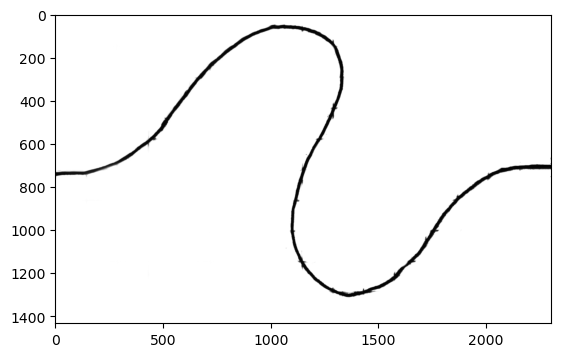

In [6]:
plt.imshow(image, cmap="binary_r")
plt.show()

Show the imported **sign** mask:

In [7]:
if sign_compute=="MASK":
    plt.imshow(mask_image, cmap="binary_r")
    plt.show()

# CREATE SCALAR FIELDS

In this step the imported image is going to be converted into an Signed Distance Function (SDF)

Create a **point cloud** object:

In [8]:
points = Points([])

Calculate the aspect ratio of the image:

In [9]:
aspect_ratio = image.shape[0]/image.shape[1]

Extract the **point cloud** from the greyscale image (first parameter).
All the pixels in the image with a brightness value below the **binary threshold** (third parameter) are included in the **point cloud** and the positions of the points are calculated from the **specified image size** (second parameter):


In [10]:
points.from_image(image, (co_size[0], co_size[0]*aspect_ratio), binary_threshold=0.5)
cloud = points.cloud

Create an **SDF** from the **point cloud**:

In [11]:
wg = PointCloud2D(cloud)

Evaluate the **SDF** to create a signed distance field 3D map:


In [12]:
wg_pattern = wg.create(coor)

**Smooth** the **SDF** to avoid artifacts in the final **vector field**:

In [13]:
wg_pattern_smooth = smarter_reshape(wg_pattern, co_resolution)
wg_pattern_smooth = conv_averaging(wg_pattern_smooth, (5, 5, 1), 1)
wg_pattern = wg_pattern_smooth.reshape(wg_pattern.shape)

In the last step we applied a single **iteration** (*third parameter*) convolutional averaging filter (`conv_averaging`) with the **kernel size** of `(5, 5, 1)` (*second_parameter*). The **kernel size** implies that we are only **smoothing** the field in the **X** and **Y** directions.

A this point the scalar field we calculated is no longer a true SDF since we smoothed the field and potentially changed the distances between points.

## Show scalar fields

(101, 101, 11)


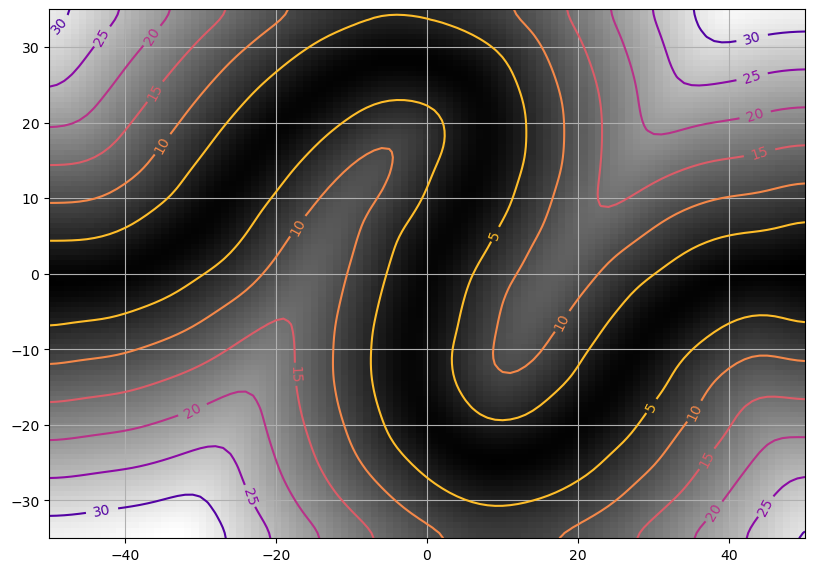

In [14]:
if show_midplane and show_field:
    field = smarter_reshape(wg_pattern, co_resolution)
    fig, ax = plt.subplots(1, 1, figsize=(8.25, 8.25))
    print(field.shape)
    ax.imshow(field[:, :, depth_index].T,
              cmap="binary_r",
              extent=(-co_size[0] / 2, co_size[0] / 2,
                      -co_size[1] / 2, co_size[1] / 2),
              origin="lower"
              )
    z_mask = coor[2] == -co_size[2]/2
    cs = ax.contour(coor[0, z_mask].reshape(co_res_new[0], co_res_new[1]),
                    coor[1, z_mask].reshape(co_res_new[0], co_res_new[1]),
                    field[:, :, depth_index],
                    cmap="plasma_r")
    ax.clabel(cs, inline=True, fontsize=10)
    ax.grid()

    fig.tight_layout()
    plt.show()

In [15]:
if show_field_3d and show_field:
    fig = go.Figure(data=go.Volume(
        x=coor[0],
        y=coor[1],
        z=coor[2],
        value=wg_pattern,
        isomin=-0,
        isomax=20,
        opacity=0.1,
        surface_count=5,
    ))

    fig.update_layout(
        scene=dict(
            aspectmode="manual",
            aspectratio=dict(x=1, y=co_size[1]/co_size[0], z=co_size[2]/co_size[0])
        )
    )

    fig.show()

# CREATE VECTOR FIELDS

To calculate the **vector field** from the **scalar field** we calculated above, we must first set correctly set the **sign** of the vector field:

In [16]:
if sign_compute == "MASK":
    # calculate the image aspect ratio
    mask_aspect_ratio = mask_image.shape[0]/mask_image.shape[1]
    # convert image into a point cloud
    mask_points = Points([])
    mask_points.from_image(mask_image,
                           (co_size[0], co_size[0] * mask_aspect_ratio),
                           binary_threshold=0.5)
    # covert point cloud to a mask
    mask_ = mask_points.to_image(co_size, co_resolution, extend=("-Z", "+Z", "-Y"))
    mask_ = 1 - mask_
    # non-zero values represent a positive sign and zero values represent a negative sign
    sign_ = 2.0*(mask_>0) - 1.0
    sign_ = sign_.flatten()
elif sign_compute == "AUTO":
    sign_ = None
else:
    sign_ = None

With the **sign** set we pass the **width** - `w` of the vector field, the **resolution of the coordinate system** - `co_resolution`, and the **sign** of the vector field into the function `LCWG2D`:

In [17]:
if vector_field_type == "2D":
    final = LCWG2D(w, co_resolution, sign_)
    coordinates = wg_pattern

To create a **vector field** which varies in all **three dimensions** we must specify at least **2** **scalar fields** - the `wg_pattern` field we calculated before and the `vertical` field below. Function `LCWG3Dm1` takes an additional parameter `co_size[2]` which described the characteristic thickness of the vector field.

In [18]:
if vector_field_type == "3D":
    vertical = Z(-co_size[2]/2).create(coor)
    final = LCWG3Dm1((w, co_size[2]), co_resolution, sign_)
    coordinates = (wg_pattern, vertical)

## EVALUATE

Evaluate the **vector field** functions to create a map of the **vector field**. This is done by calling the **create** method and passing in the point cloud of coordinates:

In [19]:
final_field = final.create(coordinates)

# EXTRACT

Extract the **x**, **y**, and **z** components of the **vector field**:

In [20]:
x = final.x(coordinates)
y = final.y(coordinates)
z = final.z(coordinates)

Extract the **phi** (azimuthal) and **theta** (polar) angles, and the vector **lengths**:

In [21]:
phi = final.phi(coordinates)
theta = final.theta(coordinates)
length = final.length(coordinates)

Convert the field maps into grids:

In [22]:
field = vector_smarter_reshape(final_field, co_resolution)
x = smarter_reshape(x, co_resolution)
y = smarter_reshape(y, co_resolution)
z = smarter_reshape(z, co_resolution)
phi = smarter_reshape(phi, co_resolution)
theta = smarter_reshape(theta, co_resolution)
length = smarter_reshape(length, co_resolution)

# PLOT

## XY plane


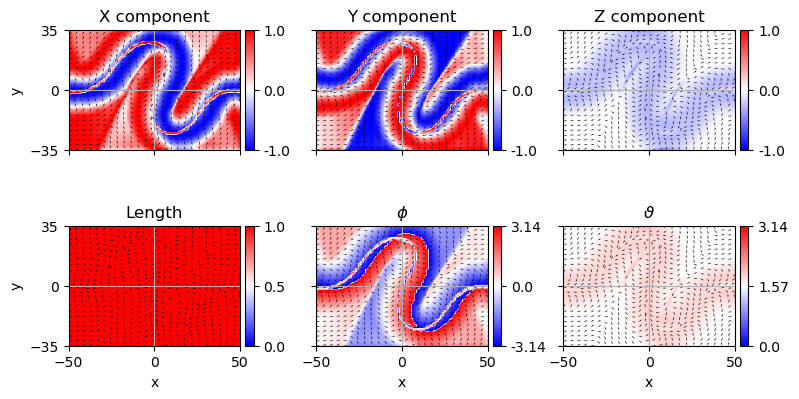

In [23]:
if show_midplane:
    fig, axs = plt.subplots(2, 3, figsize=(8.25, 1.5*8.25/3), sharex="col", sharey="row")

    patterns = ((x, y, z), (length, phi, theta))
    titles = (("X component", "Y component", "Z component"), ("Length", r"$\phi$", r"$\vartheta$"))
    mins = ((-1, -1, -1), (0, -np.pi, 0))
    maxs = ((1, 1, 1), (1, np.pi, np.pi))

    for i in range(2):
        for j in range(3):
            ax = axs[i, j]

            divider = make_axes_locatable(ax)
            cax = divider.append_axes('right', size='5%', pad=0.05)

            f = ax.imshow(patterns[i][j][:, :, depth_index].T,
                          cmap="bwr",
                          extent=(-co_size[0]/2, co_size[0]/2,
                                  -co_size[1]/2, co_size[1]/2),
                          origin="lower",
                          vmin=mins[i][j],
                          vmax=maxs[i][j]
                      )

            cbar = fig.colorbar(f, cax=cax)
            cbar.set_ticks(np.linspace(mins[i][j], maxs[i][j], 3))
            cbar.set_ticklabels(np.round(np.linspace(mins[i][j], maxs[i][j], 3), 2))

            ax.set_xticks(np.linspace(-co_size[0]/2, co_size[0]/2, 3))
            ax.set_yticks(np.linspace(-co_size[1]/2, co_size[1]/2, 3))
            ax.grid()

            ax.quiver(smarter_reshape(coor[0], co_resolution)[::decimate, ::decimate, depth_index],
                      smarter_reshape(coor[1], co_resolution)[::decimate, ::decimate, depth_index],
                      field[0, ::decimate, ::decimate, depth_index],
                      field[1, ::decimate, ::decimate, depth_index])

            if i == 1:
                ax.set_xlabel("x")
            if j == 0:
                ax.set_ylabel("y")

            ax.set_title(titles[i][j])

    fig.tight_layout()
    fig.subplots_adjust(left=0.112,
                        bottom=0.05,
                        right=0.936,
                        top=1,
                        wspace=0.336,
                        hspace=0.0)
    plt.show()

## XZ plane

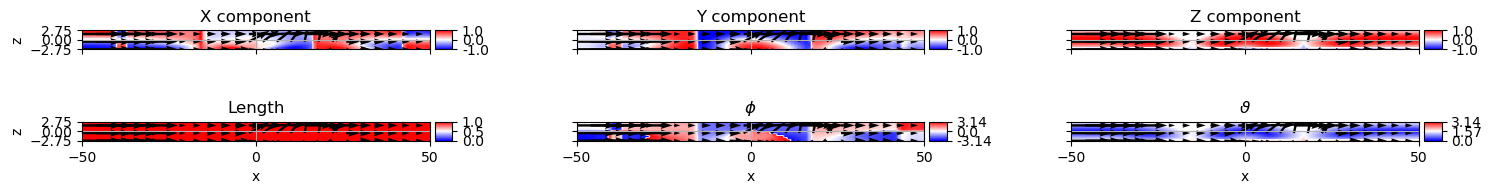

In [24]:
if show_midplane:
    fig, axs = plt.subplots(2, 3, figsize=(8.25*2, 0.7*8.25/3), sharex="col", sharey="row")

    patterns = ((x, y, z), (length, phi, theta))
    titles = (("X component", "Y component", "Z component"), ("Length", r"$\phi$", r"$\vartheta$"))
    mins = ((-1, -1, -1), (0, -np.pi, 0))
    maxs = ((1, 1, 1), (1, np.pi, np.pi))

    for i in range(2):
        for j in range(3):
            ax = axs[i, j]

            divider = make_axes_locatable(ax)
            cax = divider.append_axes('right', size='5%', pad=0.05)
            depth_index_xz = patterns[i][j].shape[1]//2
            f = ax.imshow(patterns[i][j][:, depth_index_xz, :].T,
                      cmap="bwr",
                      extent=(-co_size[0]/2, co_size[0]/2,
                              -co_size[2]/2, co_size[2]/2),
                      origin="lower",
                          vmin=mins[i][j],
                          vmax=maxs[i][j]
                      )

            cbar = fig.colorbar(f, cax=cax)
            cbar.set_ticks(np.linspace(mins[i][j], maxs[i][j], 3))
            cbar.set_ticklabels(np.round(np.linspace(mins[i][j], maxs[i][j], 3), 2))

            ax.set_xticks(np.linspace(-co_size[0]/2, co_size[0]/2, 3))
            ax.set_yticks(np.linspace(-co_size[2]/2, co_size[2]/2, 3))
            ax.grid()

            ax.quiver(smarter_reshape(coor[0], co_resolution)[::decimate, depth_index, ::decimate],
                      smarter_reshape(coor[2], co_resolution)[::decimate, depth_index, ::decimate],
                      field[0, ::decimate, depth_index, ::decimate],
                      field[2, ::decimate, depth_index, ::decimate])

            if i == 1:
                ax.set_xlabel("x")
            if j == 0:
                ax.set_ylabel("z")

            ax.set_title(titles[i][j])

    fig.tight_layout()
    fig.subplots_adjust(left=0.112,
                        bottom=0.05,
                        right=0.936,
                        top=1,
                        wspace=0.336,
                        hspace=0.0)
    plt.show()

## 3D

In [25]:
if show_3d:
    xx = smarter_reshape(coor[0], co_resolution)[::decimate, ::decimate, :].flatten()
    yy = smarter_reshape(coor[1], co_resolution)[::decimate, ::decimate, :].flatten()
    zz = smarter_reshape(coor[2], co_resolution)[::decimate, ::decimate, :].flatten()
    vx = field[0, ::decimate, ::decimate, :].flatten()
    vy = field[1, ::decimate, ::decimate, :].flatten()
    vz = field[2, ::decimate, ::decimate, :].flatten()
    phi_ = phi[::decimate, ::decimate, :].flatten()

    fig = go.Figure()

    fig = go.Figure(
        data=go.Cone(
            x=xx,
            y=yy,
            z=zz,
            u=vx,
            v=vy,
            w=vz,
            colorscale='Blues_r',
            sizemode="absolute",
            sizeref=5
        )
    )

    fig.update_layout(
        scene=dict(
            aspectmode="manual",
            aspectratio=dict(x=1, y=co_size[1]/co_size[0], z=2*co_size[2]/co_size[0])
        )
    )

    fig.show()